In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from skimage.metrics import structural_similarity as ssim

In [2]:
def add_gaussian_noise(image):
    mean = 0
    sigma = 25
    gauss = np.random.normal(mean, sigma, image.shape).astype('uint8')
    return cv2.add(image, gauss)

def add_salt_pepper_noise(image, prob=0.02):
    noisy = image.copy()
    rnd = np.random.rand(*image.shape[:2])

    noisy[rnd < prob] = 0
    noisy[rnd > 1 - prob] = 255

    return noisy

def add_speckle_noise(image):
    gauss = np.random.randn(*image.shape)
    noisy = image + image * gauss
    return np.clip(noisy, 0, 255).astype('uint8')

In [3]:
def mean_filter(image, k):
    return cv2.blur(image, (k, k))

def gaussian_filter(image, k, sigma):
    return cv2.GaussianBlur(image, (k, k), sigma)

In [4]:
def median_filter(image, k):
    return cv2.medianBlur(image, k)

def min_filter(image, k):
    kernel = np.ones((k, k), np.uint8)
    return cv2.erode(image, kernel)

In [5]:
def calculate_metrics(original, processed):
    mse = np.mean((original - processed) ** 2)
    psnr = cv2.PSNR(original, processed)

    gray1 = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(processed, cv2.COLOR_BGR2GRAY)

    ssim_val = ssim(gray1, gray2)

    return mse, psnr, ssim_val

In [6]:
# Load image
image = cv2.imread('bunga.jpeg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Generate noise
noises = {
    'gaussian': add_gaussian_noise(image),
    'salt_pepper': add_salt_pepper_noise(image),
    'speckle': add_speckle_noise(image)
}

filters = {
    'mean_3': lambda img: mean_filter(img, 3),
    'mean_5': lambda img: mean_filter(img, 5),
    'gauss_1': lambda img: gaussian_filter(img, 5, 1),
    'gauss_2': lambda img: gaussian_filter(img, 5, 2),
    'median_3': lambda img: median_filter(img, 3),
    'median_5': lambda img: median_filter(img, 5),
    'min_3': lambda img: min_filter(img, 3)
}

results = {}

for noise_name, noisy_img in noises.items():
    results[noise_name] = {}

    for fname, f in filters.items():
        start = time.time()
        filtered = f(noisy_img)
        exec_time = time.time() - start

        mse, psnr, ssim_val = calculate_metrics(image, filtered)

        results[noise_name][fname] = {
            'image': filtered,
            'mse': mse,
            'psnr': psnr,
            'ssim': ssim_val,
            'time': exec_time
        }

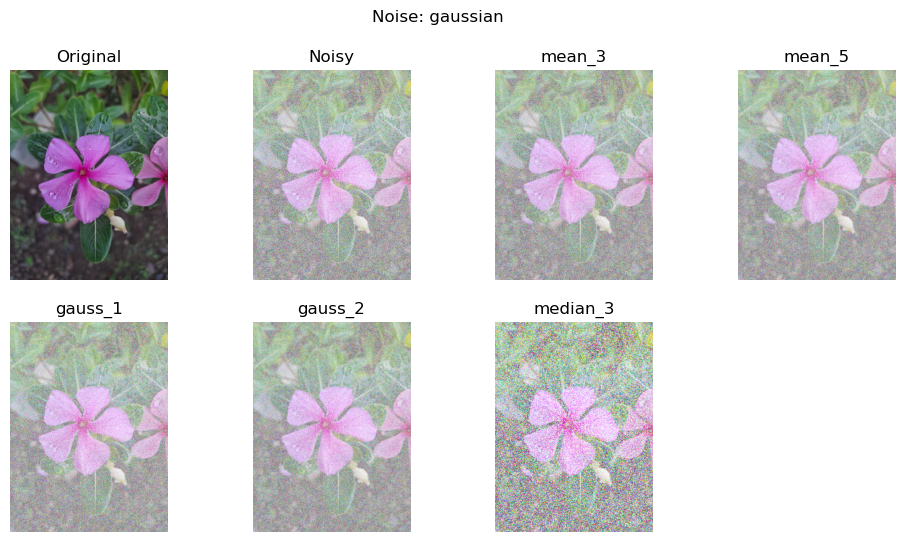

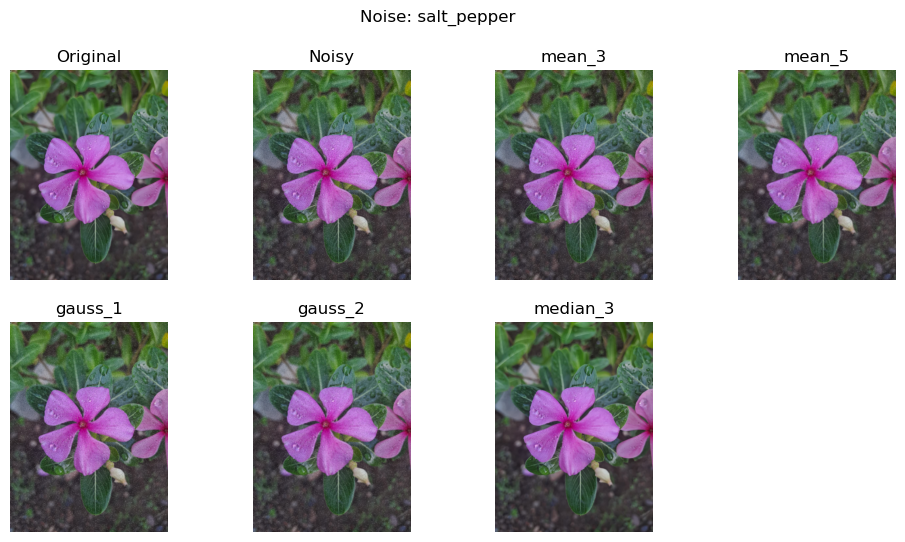

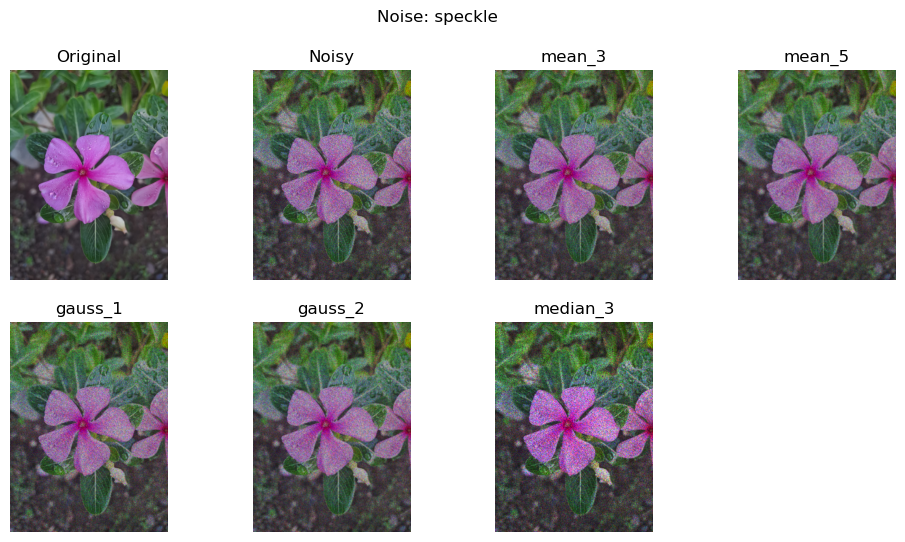

In [7]:
for noise_name in noises:
    plt.figure(figsize=(12, 6))
    plt.suptitle(f"Noise: {noise_name}")

    plt.subplot(2, 4, 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, 4, 2)
    plt.imshow(noises[noise_name])
    plt.title("Noisy")
    plt.axis('off')

    idx = 3
    for fname in list(filters.keys())[:5]:
        plt.subplot(2, 4, idx)
        plt.imshow(results[noise_name][fname]['image'])
        plt.title(fname)
        plt.axis('off')
        idx += 1

    plt.show()

In [8]:
for noise in results:
    print(f"\n=== Noise: {noise} ===")
    for f in results[noise]:
        r = results[noise][f]
        print(f"{f} | MSE: {r['mse']:.2f} | PSNR: {r['psnr']:.2f} | SSIM: {r['ssim']:.3f} | Time: {r['time']:.4f}")


=== Noise: gaussian ===
mean_3 | MSE: 108.11 | PSNR: 8.44 | SSIM: 0.213 | Time: 0.0010
mean_5 | MSE: 108.96 | PSNR: 8.64 | SSIM: 0.380 | Time: 0.0012
gauss_1 | MSE: 107.66 | PSNR: 8.52 | SSIM: 0.260 | Time: 0.0009
gauss_2 | MSE: 108.87 | PSNR: 8.63 | SSIM: 0.374 | Time: 0.0009
median_3 | MSE: 114.14 | PSNR: 6.58 | SSIM: 0.047 | Time: 0.0007
median_5 | MSE: 114.87 | PSNR: 6.74 | SSIM: 0.060 | Time: 0.0043
min_3 | MSE: 40.03 | PSNR: 27.18 | SSIM: 0.773 | Time: 0.0033

=== Noise: salt_pepper ===
mean_3 | MSE: 32.57 | PSNR: 28.17 | SSIM: 0.610 | Time: 0.0010
mean_5 | MSE: 33.47 | PSNR: 31.13 | SSIM: 0.778 | Time: 0.0011
gauss_1 | MSE: 30.06 | PSNR: 29.25 | SSIM: 0.672 | Time: 0.0007
gauss_2 | MSE: 33.84 | PSNR: 31.12 | SSIM: 0.776 | Time: 0.0008
median_3 | MSE: 2.47 | PSNR: 43.31 | SSIM: 0.987 | Time: 0.0006
median_5 | MSE: 5.56 | PSNR: 39.30 | SSIM: 0.967 | Time: 0.0038
min_3 | MSE: 36.46 | PSNR: 15.81 | SSIM: 0.286 | Time: 0.0007

=== Noise: speckle ===
mean_3 | MSE: 88.32 | PSNR: 19.77